# Purpose

Predict whether the customer who received the campaign calls would decide to subscribe to the term deposit product

# Library install

use runtime 2025.07
latest version of pycaret is only supported in python versions up until 3.11

In [ ]:
%pip install pycaret[tuners]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 978.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 16.2 MB

In [ ]:
import pycaret
pycaret.__version__

'3.3.2'

In [ ]:
%pip install hyperopt

In [ ]:
import hyperopt
hyperopt.__version__

'0.2.7'

hyperopt: hyperparam tuning based on bayesian optimization

In [ ]:
%pip install tune-sklearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: typing-inspection
    Found existing installation: typing-inspection 0.4.1
    Uninstalling typing-inspection-0.4.1:
      Successfully uninstalled typing-inspection-0.4.1
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.33.2
    Uninstalling pydantic_core-2.33.2:
      Successfully uninstalled pydantic_core-2.33.2
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.11.7
    Uninstalling pydantic-2.11.7:
      Successfully uninstalled p

In [ ]:
%pip install ray[tune]==2.7

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 MB 10.8 MB/s eta 0:00:00
  Attempting uninstall: ray
    Found existing installation: ray 2.53.0
    Uninstalling ray-2.53.0:
      Successfully uninstalled ray-2.53.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tune-sklearn 0.5.0 requires ray[tune]>=2.7.1, but you have ray 2.7.0 which is incompatible.


In [ ]:
import ray
ray.__version__

'2.7.0'

In [ ]:
import random

seed = 2694 #random.randint(1000, 9999)

# Data Import

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/My Drive/Apziva/Project 2 - Term Deposit/term-deposit-marketing-2020.csv'
df = pd.read_csv(data_path)

Mounted at /content/drive


In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
features = df[df.columns.difference(['y'])]
target = df['y']

# Split the data into training and testing sets
X_train_customer, X_test_customer, y_train_customer, y_test_customer = train_test_split(features, target, test_size=0.3, random_state=seed, stratify=target)

# Combine X_train and y_train for PyCaret's setup
df_train_customer = pd.concat([X_train_customer, y_train_customer], axis=1)

# Pycaret Model call

Train and compare machine learning models using PyCaret on the `df` DataFrame to predict the 'y' column, using all features.

## Baseline Models

In [ ]:
from pycaret.classification import *

In [ ]:
pycaret_setup = setup(data = df_train_customer, target = 'y', session_id = seed, test_data = pd.concat([X_test_customer, y_test_customer], axis=1))

,Description,Value
0,Session id,2694
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(40000, 14)"
5,Transformed data shape,"(40000, 42)"
6,Transformed train set shape,"(28000, 42)"
7,Transformed test set shape,"(12000, 42)"
8,Numeric features,5
9,Categorical features,8


In [ ]:
get_config()

{'USI',
 'X',
 'X_test',
 'X_test_transformed',
 'X_train',
 'X_train_transformed',
 'X_transformed',
 '_available_plots',
 '_ml_usecase',
 'data',
 'dataset',
 'dataset_transformed',
 'exp_id',
 'exp_name_log',
 'fix_imbalance',
 'fold_generator',
 'fold_groups_param',
 'fold_shuffle_param',
 'gpu_n_jobs_param',
 'gpu_param',
 'html_param',
 'idx',
 'is_multiclass',
 'log_plots_param',
 'logging_param',
 'memory',
 'n_jobs_param',
 'pipeline',
 'seed',
 'target_param',
 'test',
 'test_transformed',
 'train',
 'train_transformed',
 'variable_and_property_keys',
 'variables',
 'y',
 'y_test',
 'y_test_transformed',
 'y_train',
 'y_train_transformed',
 'y_transformed'}

In [ ]:
get_config('X_train_transformed')

,age,balance,campaign,contact_unknown,contact_telephone,contact_cellular,day,default,duration,education_primary,...,month_nov,month_jul,month_feb,month_jan,month_apr,month_oct,month_jun,month_aug,month_mar,month_dec
3560,57.0,1.0,10.0,1.0,0.0,0.0,15.0,0.0,17.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27709,40.0,0.0,3.0,0.0,1.0,0.0,21.0,1.0,333.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7891,42.0,1958.0,3.0,1.0,0.0,0.0,30.0,0.0,124.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16166,36.0,286.0,9.0,0.0,0.0,1.0,22.0,0.0,167.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30776,28.0,1137.0,4.0,0.0,0.0,1.0,6.0,0.0,129.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,23.0,425.0,1.0,1.0,0.0,0.0,3.0,0.0,768.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
20582,42.0,487.0,4.0,0.0,1.0,0.0,12.0,0.0,58.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
39034,33.0,2294.0,1.0,0.0,0.0,1.0,18.0,0.0,81.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20009,35.0,2957.0,3.0,0.0,0.0,1.0,8.0,0.0,733.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Model eval

In [ ]:
top_baseline_models_customer = compare_models(n_select = 3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9391,0.9507,0.9391,0.9314,0.9337,0.4691,0.4792,1.3680
gbc,Gradient Boosting Classifier,0.9380,0.9439,0.9380,0.9281,0.9304,0.4292,0.4466,4.3410
rf,Random Forest Classifier,0.9363,0.9394,0.9363,0.9246,0.9264,0.3854,0.4111,3.5610
xgboost,Extreme Gradient Boosting,0.9359,0.9457,0.9359,0.9286,0.9313,0.4555,0.4621,0.8100
lr,Logistic Regression,0.9339,0.9227,0.9339,0.9195,0.9213,0.3311,0.3639,4.4170
lda,Linear Discriminant Analysis,0.9339,0.9278,0.9339,0.9272,0.9298,0.4482,0.4529,0.5110
et,Extra Trees Classifier,0.9337,0.9237,0.9337,0.9192,0.9207,0.3241,0.3594,3.5020
ridge,Ridge Classifier,0.9319,0.9279,0.9319,0.9148,0.9116,0.2144,0.2797,0.4590
ada,Ada Boost Classifier,0.9307,0.9286,0.9307,0.9178,0.9217,0.3546,0.3708,1.5130
dummy,Dummy Classifier,0.9276,0.5000,0.9276,0.8605,0.8928,0.0000,0.0000,0.5830


Processing:   0%|          | 0/67 [00:00<?, ?it/s]

Model 1: LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=2694, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


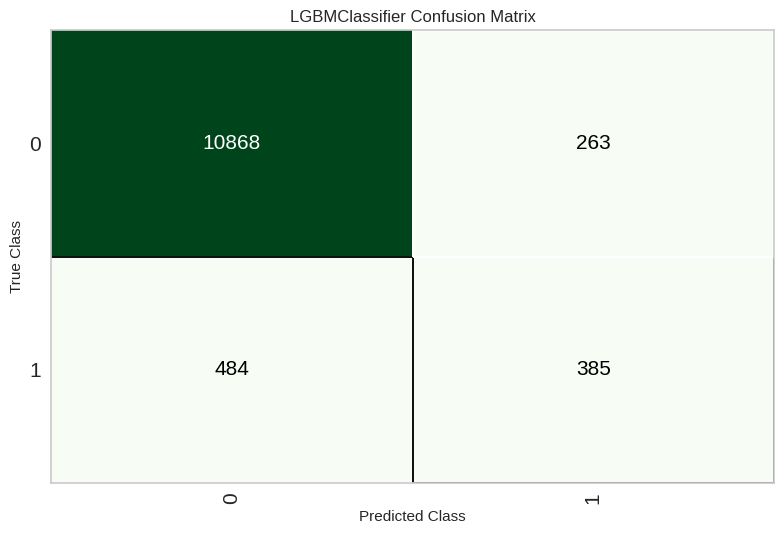

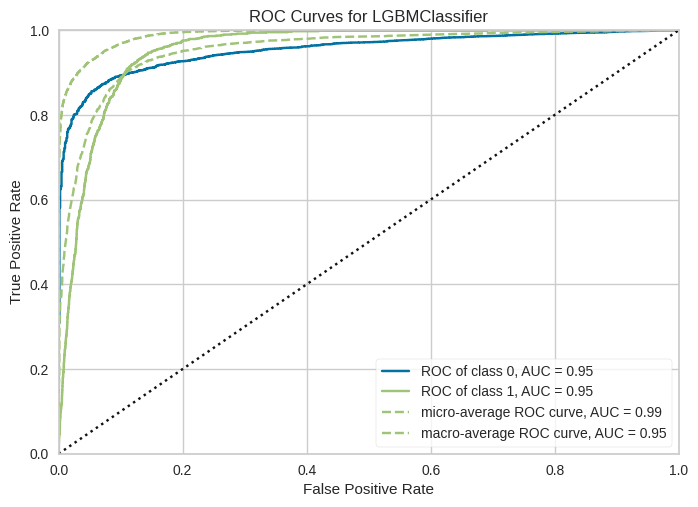

Model 2: GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=2694, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


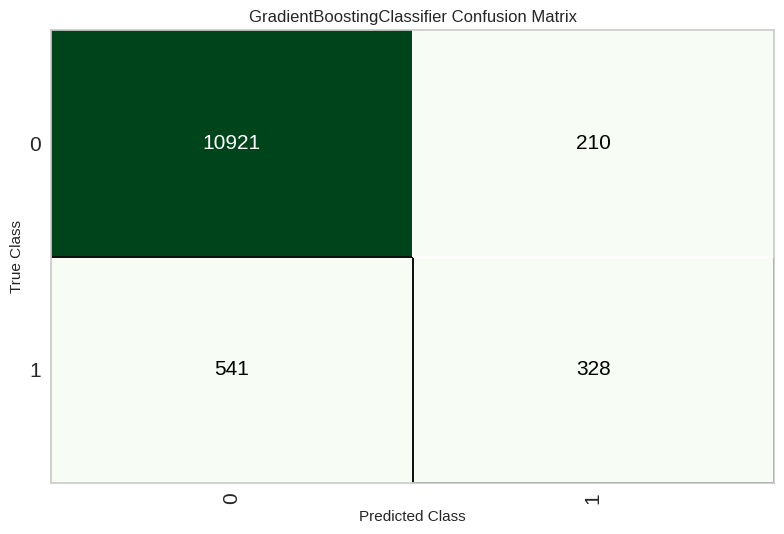

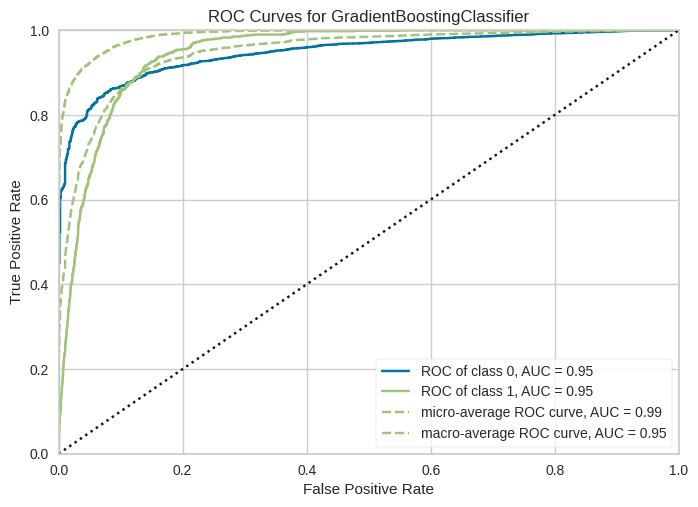

Model 3: RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=2694, verbose=0,
                       warm_start=False)


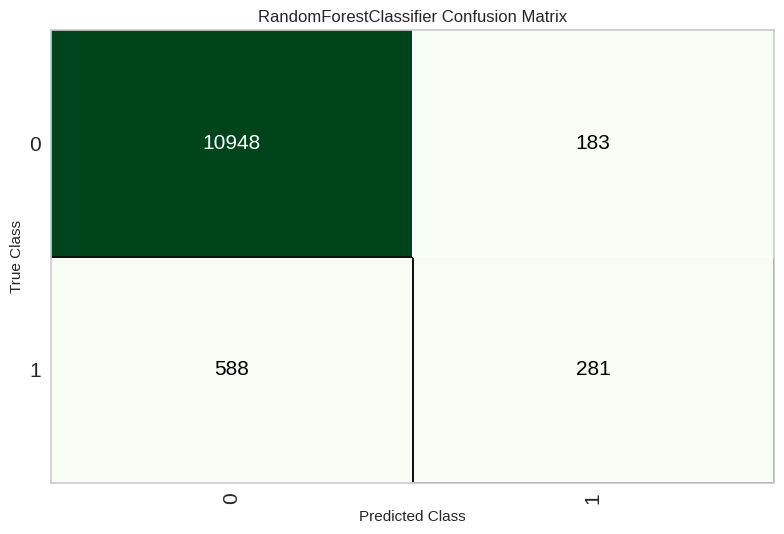

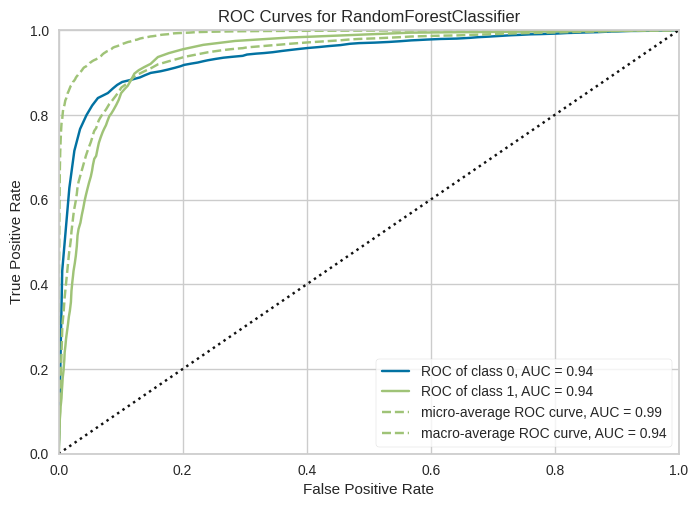

In [ ]:
for i in range(3):
  model = top_baseline_models_customer[i]
  print(f"Model {i+1}: {model}")
  plot_model(model, plot='confusion_matrix', plot_kwargs = {'figure': {'dpi': 100}})
  plot_model(model, plot='auc', plot_kwargs = {'figure': {'dpi': 100}})

## Prediction

In [ ]:
pred = predict_model(baseline_models)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9276,0.6073,0.9276,0.8604,0.8927,0.0000,0.0000


In [ ]:
pred.head()

,age,job,marital,education,default,balance,housing,loan,y,prediction_label,prediction_score
14536,33,services,divorced,secondary,no,437,yes,no,no,no,0.9210
21374,35,housemaid,married,primary,no,0,no,no,no,no,0.9492
23810,35,technician,divorced,secondary,no,515,yes,yes,no,no,0.9404
30997,41,unemployed,married,primary,no,819,no,no,no,no,0.9260
27651,37,management,single,tertiary,no,2173,no,no,no,no,0.8709


# Resample

There is an overwhelming number of non-subscribers compared to the subscribers; there's a class imbalance.


Try resampling on the trained data

- undersampling
  - random undersampling: reduce the majority class so that it has similar distribution as the minority class

- oversampling: inflates the minority class so that it has a similar distribution as the majority class
  - smote: synthetitcally generate the samples
    - smote enn
    - smote tomek

## Random Undersampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

random_undersampler = RandomUnderSampler(random_state=seed)
X_train_customer_rus, y_train_customer_rus = random_undersampler.fit_resample(X_train_customer, y_train_customer)

In [ ]:
df_train_customer_rus = pd.concat([X_train_customer_rus, y_train_customer_rus], axis=1)

setup(data = df_train_customer_rus, target = 'y', session_id = seed, test_data = pd.concat([X_test_customer, y_test_customer], axis=1))

,Description,Value
0,Session id,2694
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(16054, 14)"
5,Transformed data shape,"(16054, 42)"
6,Transformed train set shape,"(4054, 42)"
7,Transformed test set shape,"(12000, 42)"
8,Numeric features,5
9,Categorical features,8


In [ ]:
customer_rus_models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8853,0.9375,0.8853,0.8869,0.8852,0.7706,0.7721,0.8170
rf,Random Forest Classifier,0.8789,0.9325,0.8789,0.8810,0.8787,0.7578,0.7599,0.6840
xgboost,Extreme Gradient Boosting,0.8702,0.9350,0.8702,0.8712,0.8702,0.7405,0.7415,0.3160
gbc,Gradient Boosting Classifier,0.8690,0.9337,0.8690,0.8703,0.8689,0.7380,0.7393,0.7600
lr,Logistic Regression,0.8490,0.9215,0.8490,0.8494,0.8490,0.6981,0.6984,2.0590
ada,Ada Boost Classifier,0.8485,0.9192,0.8485,0.8488,0.8485,0.6971,0.6974,0.6230
et,Extra Trees Classifier,0.8468,0.9125,0.8468,0.8476,0.8467,0.6936,0.6944,0.8320
ridge,Ridge Classifier,0.8384,0.9180,0.8384,0.8402,0.8382,0.6768,0.6787,0.3080
lda,Linear Discriminant Analysis,0.8382,0.9179,0.8382,0.8400,0.8380,0.6763,0.6782,0.2230
dt,Decision Tree Classifier,0.8145,0.8145,0.8145,0.8148,0.8144,0.6290,0.6293,0.1950


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

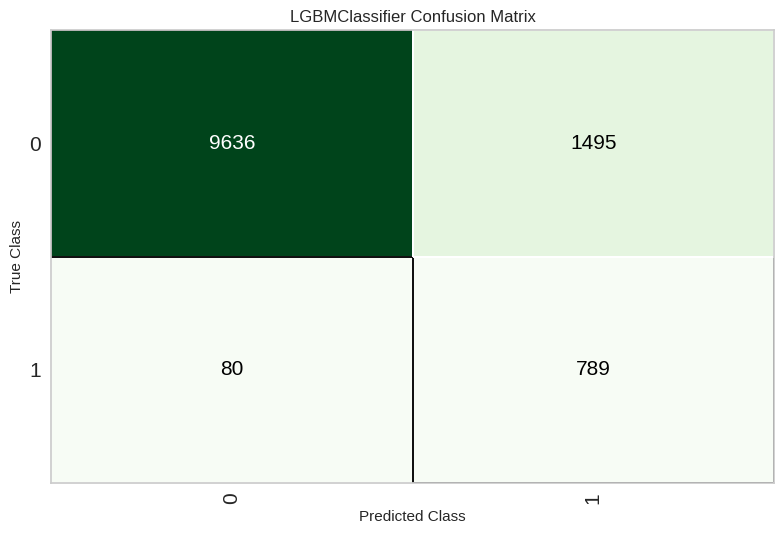

In [ ]:
plot_model(customer_rus_models, plot='confusion_matrix')

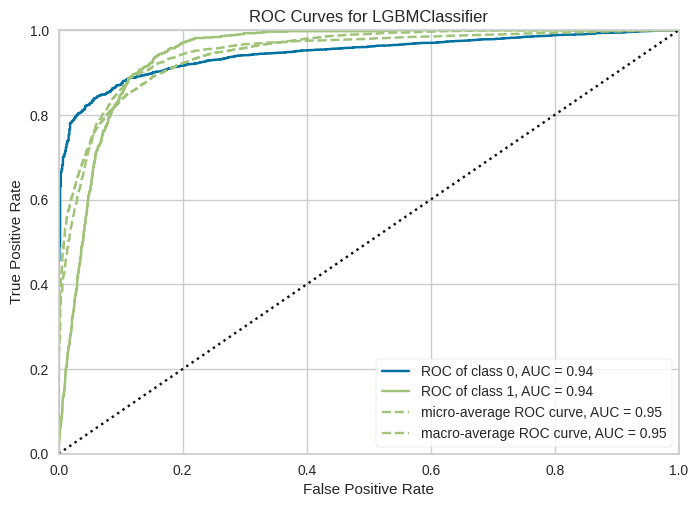

In [ ]:
plot_model(customer_rus_models, plot='auc')

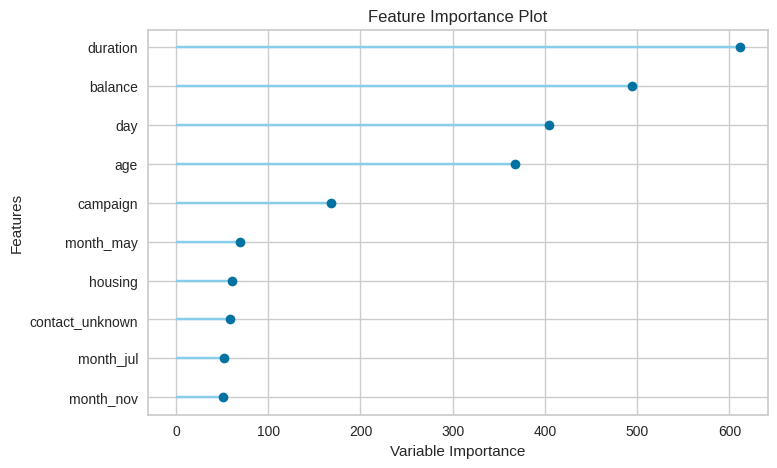

In [ ]:
plot_model(customer_rus_models, plot='feature')

In [ ]:
save_model(customer_rus_models, 'customer_rus_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['age', 'balance', 'campaign',
                                              'day', 'duration'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=Fal...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                 colsample_bytree=1.0, importance_type='split',
                                 learning_rate=0.1, max_

### Random undersampling with hyperopt

In [ ]:
tuned_customer_rus_models = tune_model(customer_rus_models, search_library = 'tune-sklearn', search_algorithm='hyperopt')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8719,0.9364,0.8719,0.8722,0.8719,0.7438,0.7442
1,0.8867,0.9511,0.8867,0.8876,0.8866,0.7734,0.7743
2,0.8719,0.9268,0.8719,0.8725,0.8719,0.7438,0.7444
3,0.8744,0.9293,0.8744,0.8764,0.8742,0.7488,0.7508
4,0.8617,0.9229,0.8617,0.8640,0.8615,0.7235,0.7258
5,0.8864,0.9334,0.8864,0.8889,0.8863,0.7729,0.7753
6,0.8716,0.9384,0.8716,0.8779,0.8711,0.7433,0.7495
7,0.8642,0.9431,0.8642,0.8653,0.8641,0.7284,0.7294
8,0.8840,0.9310,0.8840,0.8873,0.8837,0.7678,0.7713


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

2026-02-01 06:54:22,753	INFO worker.py:1642 -- Started a local Ray instance.
2026-02-01 06:54:28,631	INFO tune.py:228 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.
2026-02-01 06:54:28,638	INFO tune.py:654 -- [output] This will use the new output engine with verbosity 1. To disable the new output and use the legacy output engine, set the environment variable RAY_AIR_NEW_OUTPUT=0. For more information, please see https://github.com/ray-project/ray/issues/36949


+-------------------------------------------------------------------+
| Configuration for experiment     _Trainable_2026-02-01_06-54-28   |
+-------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                  |
| Scheduler                        FIFOScheduler                    |
| Number of trials                 10                               |
+-------------------------------------------------------------------+

View detailed results here: /root/ray_results/_Trainable_2026-02-01_06-54-28
To visualize your results with TensorBoard, run: `tensorboard --logdir /root/ray_results/_Trainable_2026-02-01_06-54-28`

Trial status: 1 PENDING
Current time: 2026-02-01 06:54:39. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+--------------------------------+
| Trial name            status   |
+--------------------------------+
| _Trainable_f2a934f8   PENDING  |
+--------------------------------+

Trial _Tr

Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


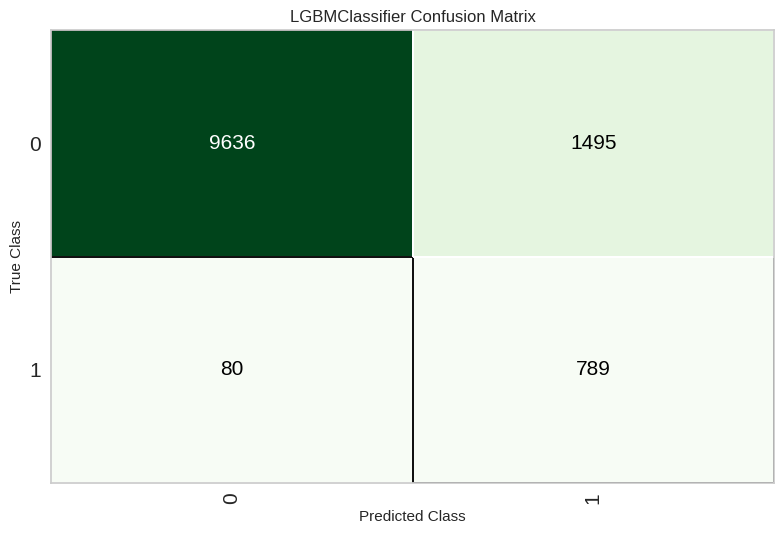

In [ ]:
plot_model(tuned_customer_rus_models, plot='confusion_matrix')

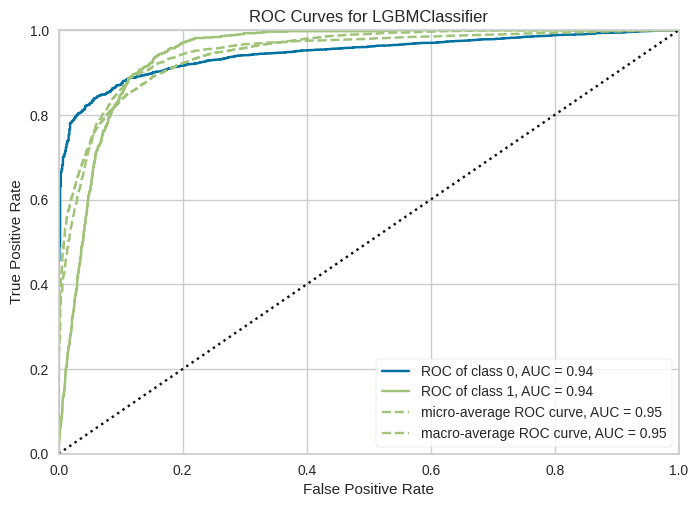

In [ ]:
plot_model(tuned_customer_rus_models, plot='auc')

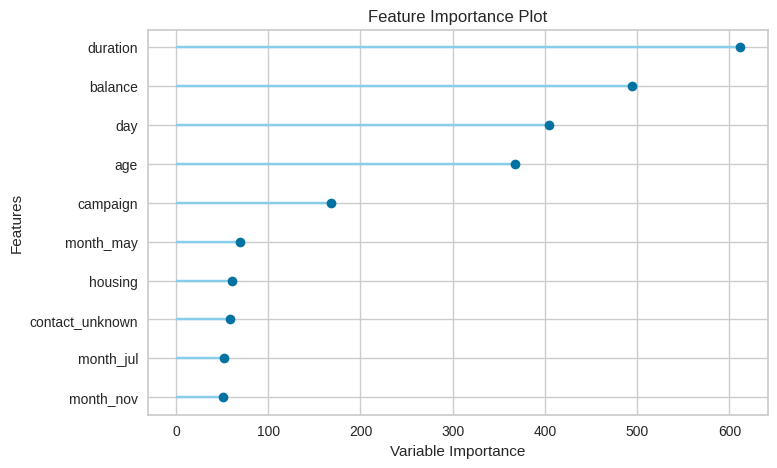

In [ ]:
plot_model(tuned_customer_rus_models, plot='feature')

## Oversampling - SMOTE ENN

In [ ]:
import pandas as pd

# Identify categorical columns in the original X_train
categorical_cols = X_train_customer.select_dtypes(include='object').columns

# Perform one-hot encoding on the categorical columns of X_train, convert boolean to int
X_train_customer_encoded = pd.get_dummies(X_train_customer, columns=categorical_cols, drop_first=True).astype(int)

# Perform one-hot encoding on the categorical columns of X_test, convert boolean to int
X_test_customer_encoded = pd.get_dummies(X_test_customer, columns=categorical_cols, drop_first=True).astype(int)

# Align columns - crucial for consistency if train/test have different category occurrences
train_customer_cols = X_train_customer_encoded.columns
test_customer_cols = X_test_customer_encoded.columns

missing_in_test = set(train_customer_cols) - set(test_customer_cols)
for c in missing_in_test:
    X_test_customer_encoded[c] = 0 # Fill with 0 for missing dummy variables

missing_in_train = set(test_customer_cols) - set(train_customer_cols)
for c in missing_in_train:
    X_train_customer_encoded[c] = 0 # Fill with 0 for missing dummy variables

X_test_customer_encoded = X_test_customer_encoded[train_customer_cols] # Ensure order and presence of all train columns

# Display the head of the encoded DataFrame to show the transformation
print("\nEncoded X_train_customer head (for SMOTEENN - integer dummified):")
display(X_train_customer_encoded.head())
print("\nEncoded X_test_customer head (for SMOTEENN - integer dummified):")
display(X_test_customer_encoded.head())


Encoded X_train_customer head (for SMOTEENN - integer dummified):


,age,balance,campaign,day,duration,contact_telephone,contact_unknown,default_yes,education_secondary,education_tertiary,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
3560,57,1,10,15,17,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
27709,40,0,3,21,333,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
7891,42,1958,3,30,124,0,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
16166,36,286,9,22,167,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
30776,28,1137,4,6,129,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0



Encoded X_test_customer head (for SMOTEENN - integer dummified):


,age,balance,campaign,day,duration,contact_telephone,contact_unknown,default_yes,education_secondary,education_tertiary,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
14536,33,437,2,15,184,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
21374,35,0,3,18,65,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
23810,35,515,3,29,114,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
30997,41,819,3,9,244,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
27651,37,2173,3,21,158,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
from imblearn.combine import SMOTEENN

# Apply SMOTEENN to the one-hot encoded X_train and y_train
smote_enn = SMOTEENN(random_state=seed)
X_train_customer_smote_enn, y_train_customer_smote_enn = smote_enn.fit_resample(X_train_customer_encoded, y_train_customer)

In [ ]:
df_train_customer_smote_enn = pd.concat([X_train_customer_smote_enn, y_train_customer_smote_enn], axis=1)

df_test_customer_smote_enn = pd.concat([X_test_customer_encoded, y_test_customer], axis=1)

# Get all column names from df_train_smote_enn that are now numerical features
# All columns except the target 'y' should now be numerical (0s, 1s, or original numerical)
all_feature_columns_customer_smote_enn = [col for col in df_train_customer_smote_enn.columns if col != 'y']

setup(data = df_train_customer_smote_enn,
      target = 'y',
      session_id = seed,
      test_data = df_test_customer_smote_enn,
      index=False,
      numeric_features=all_feature_columns_customer_smote_enn,
      categorical_features=[] # Explicitly tell PyCaret no string-based categorical features are left
     )

,Description,Value
0,Session id,2694
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(53245, 37)"
5,Transformed data shape,"(53245, 37)"
6,Transformed train set shape,"(41245, 37)"
7,Transformed test set shape,"(12000, 37)"
8,Numeric features,36
9,Preprocess,True


In [ ]:
customer_smote_enn_models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.9785,0.9960,0.9785,0.9789,0.9785,0.9566,0.9570,2.5850
rf,Random Forest Classifier,0.9696,0.9977,0.9696,0.9750,0.9692,0.9398,0.9445,4.4490
lightgbm,Light Gradient Boosting Machine,0.9691,0.9968,0.9691,0.9742,0.9688,0.9389,0.9433,1.9360
xgboost,Extreme Gradient Boosting,0.9688,0.9965,0.9688,0.9749,0.9684,0.9386,0.9438,0.9540
gbc,Gradient Boosting Classifier,0.9657,0.9940,0.9657,0.9684,0.9656,0.9314,0.9338,5.6610
lr,Logistic Regression,0.9579,0.9925,0.9579,0.9644,0.9573,0.9166,0.9221,5.3760
ada,Ada Boost Classifier,0.9575,0.9929,0.9575,0.9642,0.9569,0.9159,0.9216,1.7800
et,Extra Trees Classifier,0.9571,0.9955,0.9571,0.9704,0.9543,0.9172,0.9274,4.0300
dt,Decision Tree Classifier,0.9564,0.9564,0.9564,0.9617,0.9560,0.9132,0.9178,0.4000
ridge,Ridge Classifier,0.9392,0.9832,0.9392,0.9541,0.9350,0.8824,0.8929,0.3750


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

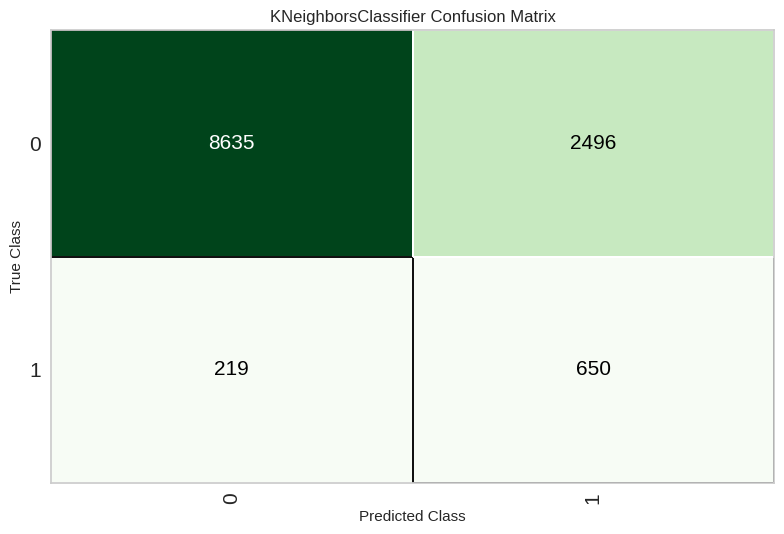

In [ ]:
plot_model(customer_smote_enn_models, plot='confusion_matrix')

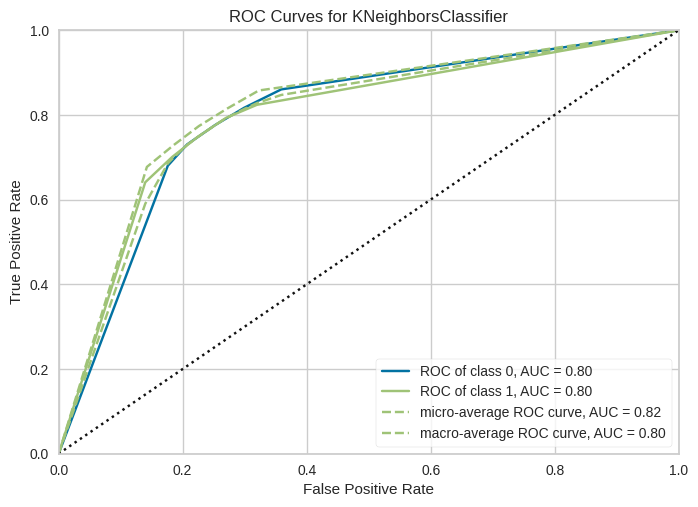

In [ ]:
plot_model(customer_smote_enn_models, plot='auc')

### Oversampling - Smote ENN with hyperopt

In [ ]:
tuned_customer_smote_enn_models = tune_model(customer_smote_enn_models, search_library = 'tune-sklearn', search_algorithm='hyperopt')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9738,0.9971,0.9738,0.9745,0.9738,0.9470,0.9478
1,0.9736,0.9948,0.9736,0.9741,0.9735,0.9465,0.9472
2,0.9775,0.9952,0.9775,0.9781,0.9774,0.9544,0.9551
3,0.9811,0.9974,0.9811,0.9815,0.9811,0.9618,0.9622
4,0.9762,0.9957,0.9762,0.9766,0.9762,0.9520,0.9524
5,0.9791,0.9935,0.9791,0.9797,0.9791,0.9578,0.9584
6,0.9794,0.9961,0.9794,0.9800,0.9793,0.9583,0.9589
7,0.9736,0.9968,0.9736,0.9743,0.9735,0.9465,0.9473
8,0.9772,0.9963,0.9772,0.9777,0.9772,0.9539,0.9545


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

2026-02-01 07:09:33,284	INFO tune.py:654 -- [output] This will use the new output engine with verbosity 1. To disable the new output and use the legacy output engine, set the environment variable RAY_AIR_NEW_OUTPUT=0. For more information, please see https://github.com/ray-project/ray/issues/36949


+-------------------------------------------------------------------+
| Configuration for experiment     _Trainable_2026-02-01_07-09-33   |
+-------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                  |
| Scheduler                        FIFOScheduler                    |
| Number of trials                 10                               |
+-------------------------------------------------------------------+

View detailed results here: /root/ray_results/_Trainable_2026-02-01_07-09-33
To visualize your results with TensorBoard, run: `tensorboard --logdir /root/ray_results/_Trainable_2026-02-01_07-09-33`

Trial status: 1 PENDING
Current time: 2026-02-01 07:09:33. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+--------------------------------+
| Trial name            status   |
+--------------------------------+
| _Trainable_9681e730   PENDING  |
+--------------------------------+

Trial _Tr

Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


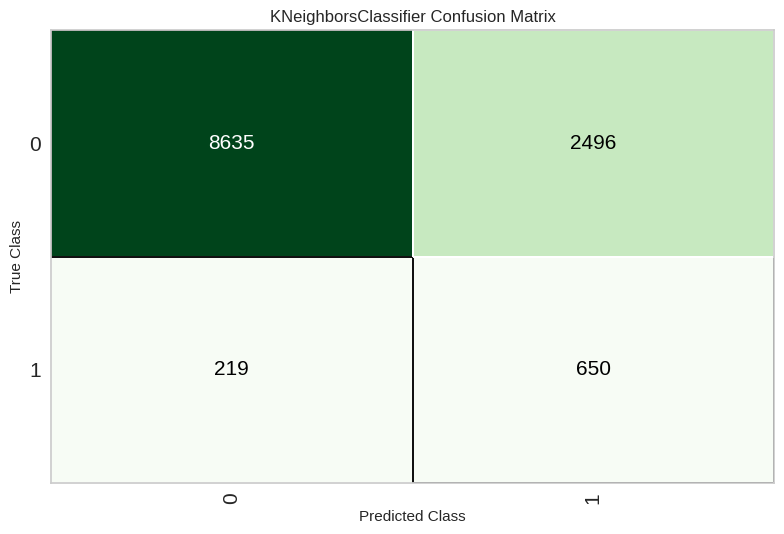

In [ ]:
plot_model(tuned_customer_smote_enn_models, plot='confusion_matrix')

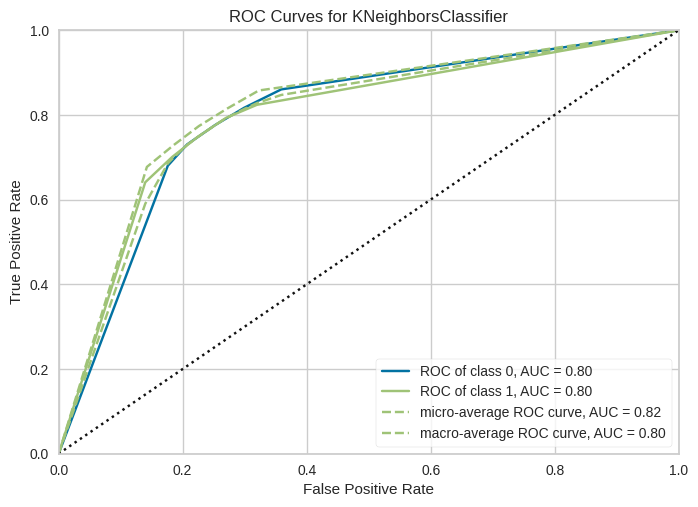

In [ ]:
plot_model(tuned_customer_smote_enn_models, plot='auc')

## Oversampling - SMOTE Tomek

In [ ]:
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=seed)
X_train_customer_smote_tomek, y_train_customer_smote_tomek = smote_tomek.fit_resample(X_train_customer_encoded, y_train_customer)

In [ ]:
df_train_customer_smote_tomek = pd.concat([X_train_customer_smote_tomek, y_train_customer_smote_tomek], axis=1)

df_test_customer_smote_tomek = pd.concat([X_test_customer_encoded, y_test_customer], axis=1)

# Get all column names from df_train_smote_enn that are now numerical features
# All columns except the target 'y' should now be numerical (0s, 1s, or original numerical)
all_feature_columns_customer_smote_tomek = [col for col in df_train_customer_smote_tomek.columns if col != 'y']

setup(data = df_train_customer_smote_tomek,
      target = 'y',
      session_id = seed,
      test_data = df_test_customer_smote_tomek,
      index=False,
      numeric_features=all_feature_columns_customer_smote_tomek,
      categorical_features=[] # Explicitly tell PyCaret no string-based categorical features are left
     )

,Description,Value
0,Session id,2694
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(62680, 37)"
5,Transformed data shape,"(62680, 37)"
6,Transformed train set shape,"(50680, 37)"
7,Transformed test set shape,"(12000, 37)"
8,Numeric features,36
9,Preprocess,True


In [ ]:
smote_tomek_customer_models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9532,0.9946,0.9532,0.9640,0.9502,0.9064,0.9160,6.2280
et,Extra Trees Classifier,0.9527,0.9905,0.9527,0.9655,0.9485,0.9055,0.9165,5.7220
xgboost,Extreme Gradient Boosting,0.9486,0.9918,0.9486,0.9593,0.9456,0.8971,0.9068,1.1450
lightgbm,Light Gradient Boosting Machine,0.9456,0.9926,0.9456,0.9562,0.9427,0.8912,0.9007,2.2190
lr,Logistic Regression,0.9408,0.9820,0.9408,0.9485,0.9388,0.8816,0.8888,7.3430
gbc,Gradient Boosting Classifier,0.9399,0.9880,0.9399,0.9472,0.9384,0.8799,0.8868,6.9760
dt,Decision Tree Classifier,0.9387,0.9387,0.9387,0.9471,0.9368,0.8773,0.8852,0.5490
ada,Ada Boost Classifier,0.9378,0.9853,0.9378,0.9473,0.9352,0.8757,0.8843,2.1680
ridge,Ridge Classifier,0.9359,0.9781,0.9359,0.9467,0.9316,0.8717,0.8810,0.2960
lda,Linear Discriminant Analysis,0.9359,0.9780,0.9359,0.9467,0.9316,0.8717,0.8810,0.4710


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

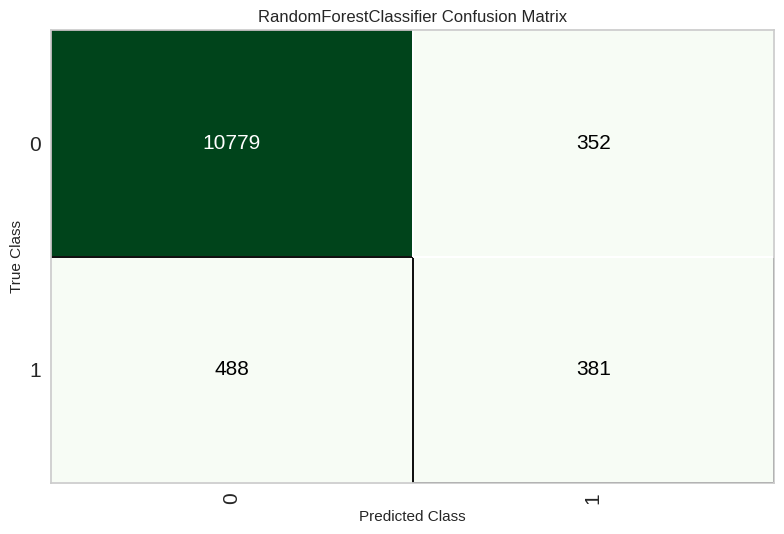

In [ ]:
plot_model(smote_tomek_customer_models, plot='confusion_matrix')

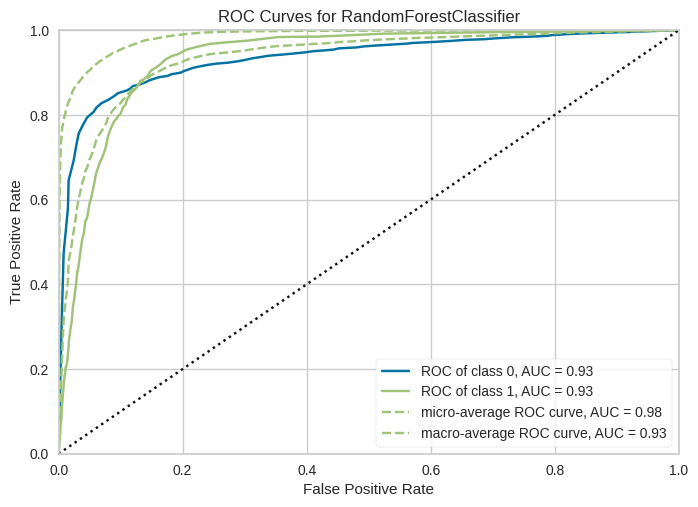

In [ ]:
plot_model(smote_tomek_customer_models, plot='auc')

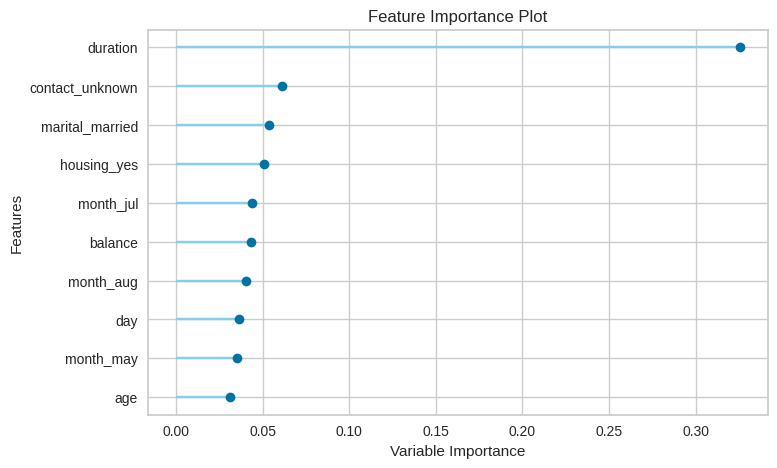

In [ ]:
plot_model(smote_tomek_customer_models, plot='feature')

### Oversampling - SMOTE Tomek with hyperopt

In [ ]:
tuned_smote_tomek_customer_models = tune_model(smote_tomek_customer_models, search_library = 'tune-sklearn', search_algorithm='hyperopt')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7824,0.9191,0.7824,0.8141,0.7767,0.5647,0.5956
1,0.9475,0.9897,0.9475,0.9485,0.9475,0.8950,0.8960
2,0.9521,0.9908,0.9521,0.9527,0.9520,0.9041,0.9048
3,0.9483,0.9896,0.9483,0.9489,0.9483,0.8966,0.8972
4,0.9479,0.9899,0.9479,0.9484,0.9479,0.8958,0.8963
5,0.9442,0.9903,0.9442,0.9454,0.9441,0.8883,0.8896
6,0.9457,0.9898,0.9457,0.9467,0.9457,0.8915,0.8925
7,0.9467,0.9917,0.9467,0.9481,0.9467,0.8934,0.8948
8,0.9473,0.9893,0.9473,0.9484,0.9473,0.8946,0.8957


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

2026-02-01 07:34:14,528	INFO tune.py:654 -- [output] This will use the new output engine with verbosity 1. To disable the new output and use the legacy output engine, set the environment variable RAY_AIR_NEW_OUTPUT=0. For more information, please see https://github.com/ray-project/ray/issues/36949


+-------------------------------------------------------------------+
| Configuration for experiment     _Trainable_2026-02-01_07-34-14   |
+-------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                  |
| Scheduler                        FIFOScheduler                    |
| Number of trials                 10                               |
+-------------------------------------------------------------------+

View detailed results here: /root/ray_results/_Trainable_2026-02-01_07-34-14
To visualize your results with TensorBoard, run: `tensorboard --logdir /root/ray_results/_Trainable_2026-02-01_07-34-14`

Trial status: 1 PENDING
Current time: 2026-02-01 07:34:14. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+--------------------------------+
| Trial name            status   |
+--------------------------------+
| _Trainable_5ad11b9e   PENDING  |
+--------------------------------+

Trial _Tr

Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


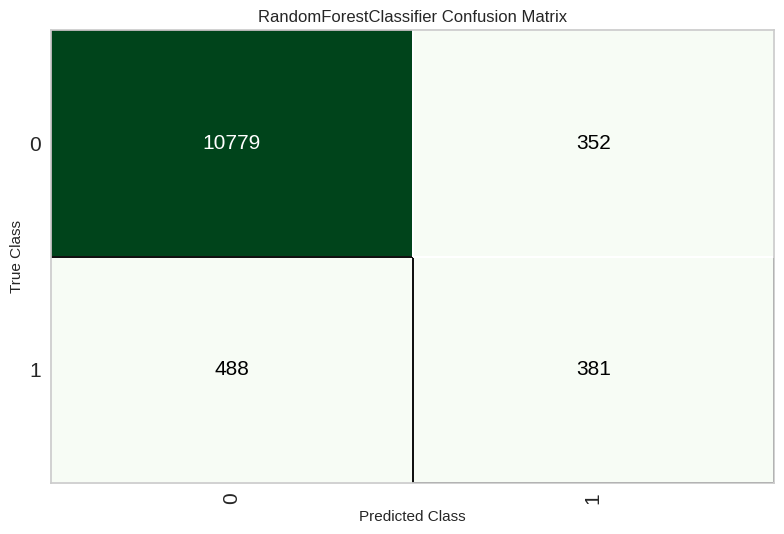

In [ ]:
plot_model(tuned_smote_tomek_customer_models, plot='confusion_matrix')

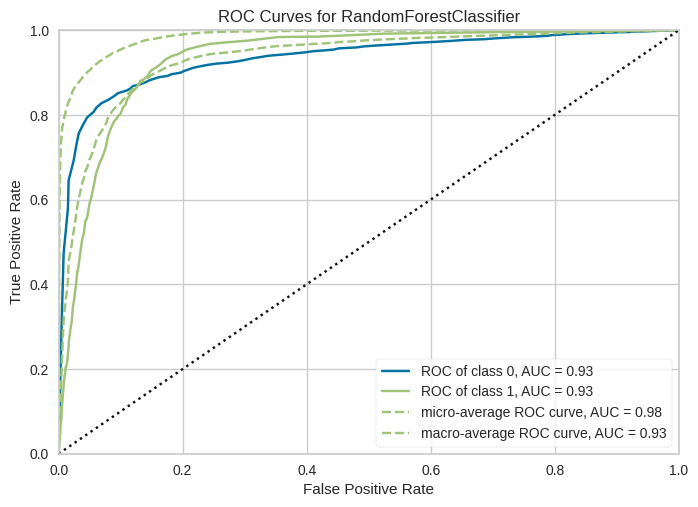

In [ ]:
plot_model(tuned_smote_tomek_customer_models, plot='auc')

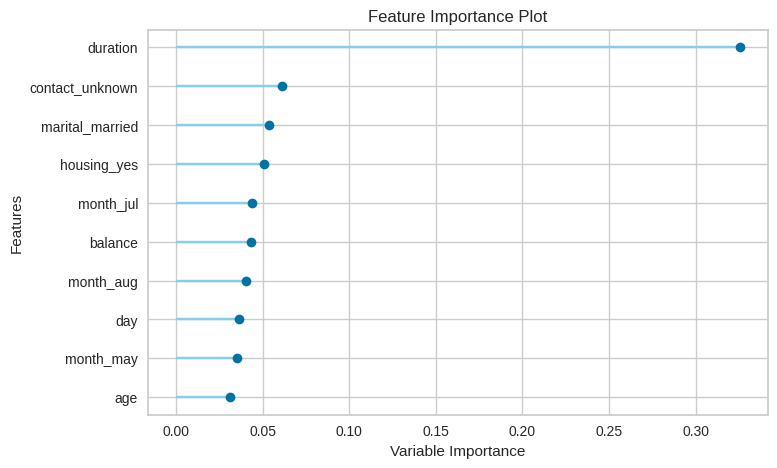

In [ ]:
plot_model(tuned_smote_tomek_customer_models, plot='feature')

# End-to-End Model Evaluation using the test dataset

Integrating
- Model 1 (Predict which of the customers should be targeted for the campaign calls) and
- Model 2 (Predict whether the customer would received the campaign calls would subscribe to the term deposit product)

In [ ]:
from pycaret.classification import load_model

# Define the path to the model file in Google Drive (without .pkl extension for load_model)
model_path_call_recipient = '/content/drive/My Drive/Apziva/Project 2 - Term Deposit/rus_model_call_target_customers'

# Load the model
loaded_call_recipient_model = load_model(model_path_call_recipient)

print('Model loaded successfully:')
print(loaded_call_recipient_model)

Transformation Pipeline and Model Successfully Loaded
Model loaded successfully:
Pipeline(memory=Memory(location=None),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(include=['age', 'balance'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['job', 'marital', 'education',
                                             'default', 'housing', 'loan'],
                                    transformer=SimpleImputer...
yes    1
NaN   -1
dtype: int64},
                                                                        {'col': 'loan',
                                                                         'data_type': dtype('O'),
                                                                         'mapping': no     0
yes    1
NaN   -1
dtype: int64

In [ ]:
# Define features (X) and target (y)
features_without_campaign = df[df.columns.difference(['y', 'contact', 'day', 'month', 'duration', 'campaign'])]
target = df['y']

# Split the data into training and testing sets
X_train_call_recipient, X_test_call_recipient, y_train_call_recipient, y_test_call_recipient = train_test_split(features_without_campaign, target, test_size=0.3, random_state=seed, stratify=target)

# Combine X_train and y_train for PyCaret's setup
df_train_call_recipient = pd.concat([X_train_call_recipient, y_train_call_recipient], axis=1)

In [ ]:
setup(data = df_train_call_recipient, target = 'y', session_id = seed, test_data = pd.concat([X_test_call_recipient, y_test_call_recipient], axis=1))

,Description,Value
0,Session id,2694
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(40000, 9)"
5,Transformed data shape,"(40000, 25)"
6,Transformed train set shape,"(28000, 25)"
7,Transformed test set shape,"(12000, 25)"
8,Numeric features,2
9,Categorical features,6


In [ ]:
pred_call_recipient = predict_model(loaded_call_recipient_model, X_test_call_recipient)

In [ ]:
pred_call_recipient.head()

,age,balance,default,education,housing,job,loan,marital,prediction_label,prediction_score
14536,33,437,no,secondary,yes,services,no,divorced,yes,0.5251
21374,35,0,no,primary,no,housemaid,no,married,no,0.6873
23810,35,515,no,secondary,yes,technician,yes,divorced,yes,0.5015
30997,41,819,no,primary,no,unemployed,no,married,yes,0.5598
27651,37,2173,no,tertiary,no,management,no,single,yes,0.6997


In [ ]:
from sklearn.metrics import accuracy_score

# Extract the prediction labels from pred_call_recipient
predictions_call_recipient = pred_call_recipient['prediction_label']

# Align predictions with the true labels
predictions_aligned_call_recipient = predictions_call_recipient.reindex(y_test_call_recipient.index)

# Calculate accuracy
accuracy_call_recipient = accuracy_score(y_test_call_recipient, predictions_aligned_call_recipient)

print(f"Accuracy of pred_call_recipient on X_test_call_recipient and y_test_call_recipient: {accuracy_call_recipient:.4f}")

Accuracy of pred_call_recipient on X_test_call_recipient and y_test_call_recipient: 0.5984


In [ ]:
X_call_recipients = X_test_customer[pred_call_recipient['prediction_label'] == 'yes']
X_call_recipients.head()

,age,balance,campaign,contact,day,default,duration,education,housing,job,loan,marital,month
14536,33,437,2,cellular,15,no,184,secondary,yes,services,no,divorced,jul
23810,35,515,3,cellular,29,no,114,secondary,yes,technician,yes,divorced,aug
30997,41,819,3,cellular,9,no,244,primary,no,unemployed,no,married,feb
27651,37,2173,3,cellular,21,no,158,tertiary,no,management,no,single,nov
21751,44,1802,5,telephone,19,no,105,tertiary,no,management,no,married,aug


In [ ]:
y_call_recipients = y_test_call_recipient[pred_call_recipient['prediction_label'] == 'yes']
y_call_recipients.head()

,y
14536,no
23810,no
30997,no
27651,no
21751,no


In [ ]:
setup(data = df_train_customer, target = 'y', session_id = seed, test_data = pd.concat([X_call_recipients, y_call_recipients], axis=1))

,Description,Value
0,Session id,2694
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(32946, 14)"
5,Transformed data shape,"(32946, 42)"
6,Transformed train set shape,"(28000, 42)"
7,Transformed test set shape,"(4946, 42)"
8,Numeric features,5
9,Categorical features,8


In [ ]:
pred_subscribe = predict_model(customer_rus_models, X_call_recipients)

In [ ]:
pred_subscribe.head()

,age,balance,campaign,contact,day,default,duration,education,housing,job,loan,marital,month,prediction_label,prediction_score
14536,33,437,2,cellular,15,no,184,secondary,yes,services,no,divorced,jul,no,0.9695
23810,35,515,3,cellular,29,no,114,secondary,yes,technician,yes,divorced,aug,no,0.9883
30997,41,819,3,cellular,9,no,244,primary,no,unemployed,no,married,feb,yes,0.5477
27651,37,2173,3,cellular,21,no,158,tertiary,no,management,no,single,nov,no,0.9046
21751,44,1802,5,telephone,19,no,105,tertiary,no,management,no,married,aug,no,0.9907


In [ ]:
from sklearn.metrics import accuracy_score

# Extract the prediction labels from pred_subscribe
predictions = pred_subscribe['prediction_label']

# Ensure both are aligned (they should be, given how X_call_recipients and y_call_recipients were created)
# However, it's good practice to ensure index alignment for direct comparison.
# y_call_recipients already has the correct index from the original split.
# We need to make sure predictions also has the same index or reindex it.

# Reindex predictions to match y_call_recipients to ensure correct comparison
predictions_aligned = predictions.reindex(y_call_recipients.index)

# Calculate accuracy
accuracy = accuracy_score(y_call_recipients, predictions_aligned)

print(f"Accuracy of pred_subscribe on X_call_recipients and y_call_recipients: {accuracy:.4f}")

Accuracy of pred_subscribe on X_call_recipients and y_call_recipients: 0.8374


# End-to-End Model Evaluation using the entire dataset

In [ ]:
features_without_campaign = df[df.columns.difference(['y', 'contact', 'day', 'month', 'duration', 'campaign'])]

In [ ]:
features_without_campaign.shape

(40000, 8)

In [ ]:
pred_call_recipient_entire_dataset = predict_model(loaded_call_recipient_model, features_without_campaign)

In [ ]:
call_recipients_entire = features_without_campaign[pred_call_recipient_entire_dataset['prediction_label'] == 'yes']

In [ ]:
call_recipients_entire.head()

,age,balance,default,education,housing,job,loan,marital
0,58,2143,no,tertiary,yes,management,no,married
6,28,447,no,tertiary,yes,management,yes,single
9,43,593,no,secondary,yes,technician,no,single
11,29,390,no,secondary,yes,admin,no,single
23,25,50,no,secondary,yes,services,no,married


In [ ]:
call_recipients_entire.shape

(16426, 8)

Accuracy of the first model (predicting call recipients) on the entire dataset: 0.6041


<Figure size 600x600 with 0 Axes>

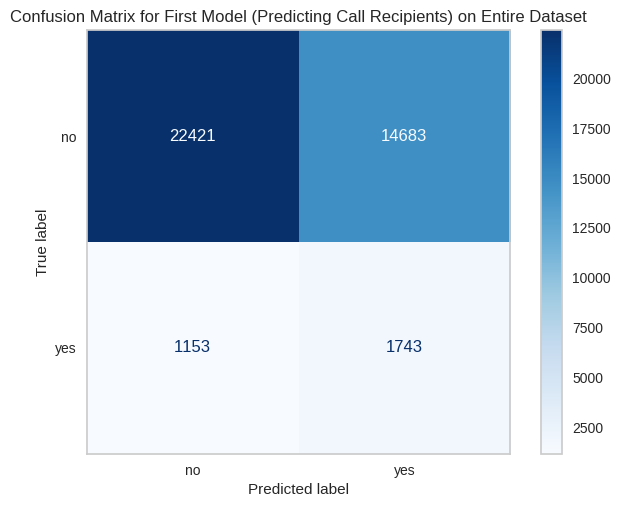


Classification Report for First Model (Predicting Call Recipients) on Entire Dataset:
              precision    recall  f1-score   support

          no       0.95      0.60      0.74     37104
         yes       0.11      0.60      0.18      2896

    accuracy                           0.60     40000
   macro avg       0.53      0.60      0.46     40000
weighted avg       0.89      0.60      0.70     40000



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels for the entire dataset
y_true_first_model_entire_df = df['y']

# Get predicted labels from the first model applied to the entire dataset
y_pred_first_model_entire_df = pred_call_recipient_entire_dataset['prediction_label']

# Ensure indices are aligned (they should be, as pred_call_recipient_entire_dataset is based on df's structure)
y_true_first_model_entire_df_aligned = y_true_first_model_entire_df.reindex(y_pred_first_model_entire_df.index)

# Calculate accuracy
accuracy_first_model_entire_df = accuracy_score(y_true_first_model_entire_df_aligned, y_pred_first_model_entire_df)
print(f"Accuracy of the first model (predicting call recipients) on the entire dataset: {accuracy_first_model_entire_df:.4f}")

# Plot Confusion Matrix
labels = sorted(y_true_first_model_entire_df_aligned.unique().tolist())

cm_first_model = confusion_matrix(y_true_first_model_entire_df_aligned, y_pred_first_model_entire_df, labels=labels)
cmd_obj_first_model = ConfusionMatrixDisplay(cm_first_model, display_labels=labels)

plt.figure(figsize=(6, 6))
cmd_obj_first_model.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for First Model (Predicting Call Recipients) on Entire Dataset')
plt.grid(False) # Remove grid lines if any
plt.show()

# Also provide classification report
print("\nClassification Report for First Model (Predicting Call Recipients) on Entire Dataset:")
print(classification_report(y_true_first_model_entire_df_aligned, y_pred_first_model_entire_df, labels=labels))

In [ ]:
total_duration_entire_dataset = df['duration'].sum()
print(f"Total call duration for the entire dataset (in seconds): {total_duration_entire_dataset}")
print(f"Total call duration for the entire dataset (in hours): {total_duration_entire_dataset / 60 / 60 :.2f}")

Total call duration for the entire dataset (in seconds): 10192972
Total call duration for the entire dataset (in hours): 2831.38


In [ ]:
# Get the indices of the call recipients from the entire dataset
call_recipient_indices = call_recipients_entire.index
# Identify customers who are NOT in call_recipients_entire
non_call_recipient_indices = df.index.difference(call_recipient_indices)

# Filter the original DataFrame to get the 'duration' for these non-recipients
duration_for_non_recipients = df.loc[non_call_recipient_indices, 'duration']

# Compute the total call duration for non-recipients
total_call_duration_for_non_recipients = duration_for_non_recipients.sum()

print(f"\nTotal call duration eliminated for customers who were not contacted (in seconds): {total_call_duration_for_non_recipients}")
print(f"Total call duration eliminated for customers who were not contacted (in hours): {total_call_duration_for_non_recipients / 60 / 60:.2f}")


Total call duration eliminated for customers who were not contacted (in seconds): 5773721
Total call duration eliminated for customers who were not contacted (in hours): 1603.81


In [ ]:
# Get duration and campaign values for identified recipients from the original df
duration_for_recipients = df.loc[call_recipient_indices, 'duration']
campaign_for_recipients = df.loc[call_recipient_indices, 'campaign']

# Calculate duration per campaign for each recipient
duration_per_campaign_for_recipients = duration_for_recipients / campaign_for_recipients

# Sum the duration per campaign to get the approximation of the first call duration
sum_duration_per_campaign = duration_per_campaign_for_recipients.sum()

print(f"Approximation of first call duration for identified recipients (in seconds): {sum_duration_per_campaign:.2f}")
print(f"Approximation of first call duration for identified recipients (in hours): {sum_duration_per_campaign / 60 / 60:.2f}")

Approximation of first call duration for identified recipients (in seconds): 2712568.59
Approximation of first call duration for identified recipients (in hours): 753.49


In [ ]:
remaining_call_duration_per_recipient = duration_for_recipients - duration_per_campaign_for_recipients

# Sum the remaining call duration for all recipients
total_remaining_call_duration = remaining_call_duration_per_recipient.sum()

print(f"Total approximated remaining call duration for identified recipients (in seconds): {total_remaining_call_duration:.2f}")
print(f"Total approximated remaining call duration for identified recipients (in hours): {total_remaining_call_duration / 60 / 60:.2f}")

Total approximated remaining call duration for identified recipients (in seconds): 1706682.41
Total approximated remaining call duration for identified recipients (in hours): 474.08


In [ ]:
features = df[df.columns.difference(['y'])]

In [ ]:
call_recipients_entire_feature = features.loc[call_recipients_entire.index]

In [ ]:
from pycaret.classification import load_model

# Define the path to the model file
model_path_customer_rus = '/content/customer_rus_model'

# Load the model
loaded_customer_rus_model = load_model(model_path_customer_rus)

print('Model loaded successfully:')
print(loaded_customer_rus_model)

Transformation Pipeline and Model Successfully Loaded
Model loaded successfully:
Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['age', 'balance', 'campaign',
                                             'day', 'duration'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_f...
                 LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                colsample_bytree=1.0, importance_typ

In [ ]:
pred_subscribe_entire = predict_model(loaded_customer_rus_model, call_recipients_entire_feature)

In [ ]:
pred_subscribe_entire.head()

,age,balance,campaign,contact,day,default,duration,education,housing,job,loan,marital,month,prediction_label,prediction_score
0,58,2143,1,unknown,5,no,261,tertiary,yes,management,no,married,may,no,0.9747
6,28,447,1,unknown,5,no,217,tertiary,yes,management,yes,single,may,no,0.9942
9,43,593,1,unknown,5,no,55,secondary,yes,technician,no,single,may,no,0.9986
11,29,390,1,unknown,5,no,137,secondary,yes,admin,no,single,may,no,0.9932
23,25,50,1,unknown,5,no,342,secondary,yes,services,no,married,may,no,0.9911


In [ ]:
subscribe_entire = features.loc[pred_subscribe_entire.index][pred_subscribe_entire['prediction_label'] == 'yes']
print("Features for customers predicted to subscribe (head):")
display(subscribe_entire.head())
print(f"Number of customers predicted to subscribe: {len(subscribe_entire)}")

Features for customers predicted to subscribe (head):


,age,balance,campaign,contact,day,default,duration,education,housing,job,loan,marital,month
38,36,506,1,unknown,5,no,577,secondary,yes,admin,no,divorced,may
53,42,-76,1,unknown,5,no,787,secondary,yes,admin,no,single,may
66,60,100,1,unknown,5,no,528,tertiary,no,retired,no,married,may
87,41,1270,1,unknown,5,no,1389,secondary,yes,technician,no,married,may
151,26,0,2,unknown,5,no,610,secondary,yes,student,no,single,may


Number of customers predicted to subscribe: 4204


Accuracy of the second model (predicting subscription) on the identified call recipients: 0.8445


<Figure size 600x600 with 0 Axes>

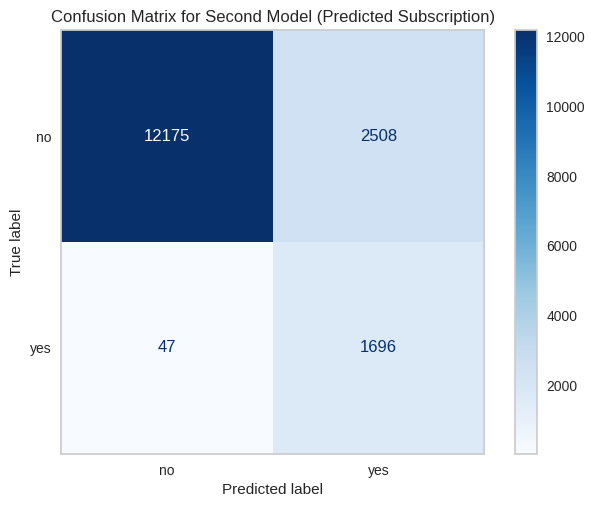


Classification Report for Second Model (Predicted Subscription):
              precision    recall  f1-score   support

          no       1.00      0.83      0.91     14683
         yes       0.40      0.97      0.57      1743

    accuracy                           0.84     16426
   macro avg       0.70      0.90      0.74     16426
weighted avg       0.93      0.84      0.87     16426



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels for the dataset used for the second model's prediction
y_true_second_model = df.loc[call_recipients_entire_feature.index, 'y']

# Get predicted labels from pred_subscribe_entire
y_pred_second_model = pred_subscribe_entire['prediction_label']

# Ensure y_true_second_model and y_pred_second_model have aligned indices for comparison
y_true_second_model_aligned = y_true_second_model.reindex(y_pred_second_model.index)

# Calculate accuracy
accuracy_second_model = accuracy_score(y_true_second_model_aligned, y_pred_second_model)
print(f"Accuracy of the second model (predicting subscription) on the identified call recipients: {accuracy_second_model:.4f}")

# Plot Confusion Matrix
# Determine unique labels in the true and predicted sets to ensure the confusion matrix has correct labels
labels = sorted(y_true_second_model_aligned.unique().tolist())

cm = confusion_matrix(y_true_second_model_aligned, y_pred_second_model, labels=labels)
cmd_obj = ConfusionMatrixDisplay(cm, display_labels=labels)

plt.figure(figsize=(6, 6))
cmd_obj.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Second Model (Predicted Subscription)')
plt.grid(False) # Remove grid lines if any
plt.show()

# Also provide classification report for more detailed metrics
print("\nClassification Report for Second Model (Predicted Subscription):")
print(classification_report(y_true_second_model_aligned, y_pred_second_model, labels=labels))

# Conclusion

The firm has invested about 2,831 hours on campaign calls to 40,000 customers, yielding a success rate of 7.24%. To improve efficiency, I implemented a two-stage Machine Learning solution to identify and target customers with the highest propensity to accept product offers. The first model identifies high-priority customers for the campaign by analyzing demographic and financial data. The second model predicts whether the identified group would accept the product offer.

The first model has achieved an accuracy of 60.4%. By identifying 16,426 high-priority leads and eliminating 23,574 low-probability prospects, the model successfully reclaimed 1,604 hours of previously wasted campaign time. For the high-priority leads, approximately 753.5 hours were spent on the initial call, with an additional 474.1 hours dedicated to follow-up conversions.

The second model was applied to the 16,426 high-priority leads to predict product offer acceptance. It demonstrated 84.5% accuracy in conversion prediction, successfully capturing 1,743 true positives.

My approach showed a significant improvement over the 7% baseline and optimized the campaign by eliminating over 1,600 hours of unproductive call time.